# 06 Final Modeling (03 Reproduction + Combined Features)

This notebook reproduces the modeling flow from `03_prem_modeling.ipynb` and applies it to the merged datasets created in `05_Combine_All_Features.ipynb`.

Main phases:
1. Load combined train/validation frames
2. Temporal cleanup + missing handling
3. Spatial clustering (KMeans)
4. Feature-set experiments (baseline, curated, enhanced)
5. Model family comparison (RF, XGBoost, LightGBM + log1p)
6. Hyperparameter tuning
7. Feature importance diagnostics
8. Final training + submission export

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform

# Optional boosting libraries (same model families as 03)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

RANDOM_STATE = 42
N_FOLDS = 5
TARGETS = ["Total Alkalinity", "Electrical Conductance", "Dissolved Reactive Phosphorus"]

print("Libraries loaded.")
print({"xgboost": HAS_XGB, "lightgbm": HAS_LGBM})

Libraries loaded.
{'xgboost': True, 'lightgbm': True}


In [47]:
# Load combined features created in 05_Combine_All_Features.ipynb
train_df = pd.read_csv("combined_features_training.csv")
val_df = pd.read_csv("combined_features_validation.csv")
submission_template = pd.read_csv("submission_template.csv")

print(f"Training combined:   {train_df.shape}")
print(f"Validation combined: {val_df.shape}")
print(f"Submission template: {submission_template.shape}")

Training combined:   (9319, 66)
Validation combined: (200, 66)
Submission template: (200, 6)


In [53]:
import pandas as pd
# assuming df is your DataFrame
non_numeric_df = train_df.select_dtypes(exclude=['number'])
print(non_numeric_df.head())

  Sample Date  season
0  02-01-2011  summer
1  03-01-2011  summer
2  03-01-2011  summer
3  03-01-2011  summer
4  03-01-2011  summer


In [ ]:
# # Temporal features and missingness handling (matching 03 style)
def add_temporal_features(df):
    df = df.copy()
    df["Sample Date"] = pd.to_datetime(df["Sample Date"], format="%d-%m-%Y", errors="coerce")
    df["Year"] = df["Sample Date"].dt.year

    season_categories = ["summer", "autumn", "winter", "spring"]
    season_dummies = pd.get_dummies(
        pd.Categorical(df["season"], categories=season_categories),
        prefix="season",
        dtype=float,
    )
    df = pd.concat([df, season_dummies], axis=1)
    return df

train_df = add_temporal_features(train_df)
val_df = add_temporal_features(val_df)

if "nir" in train_df.columns:
    train_df["landsat_missing"] = train_df["nir"].isnull().astype(float)
else:
    train_df["landsat_missing"] = 0.0

if "nir" in val_df.columns:
    val_df["landsat_missing"] = val_df["nir"].isnull().astype(float)
else:
    val_df["landsat_missing"] = 0.0

numeric_cols_train = train_df.select_dtypes(include=[np.number]).columns
train_df[numeric_cols_train] = train_df[numeric_cols_train].fillna(train_df[numeric_cols_train].median())

numeric_cols_val = val_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols_val:
    if col in train_df.columns:
        val_df[col] = val_df[col].fillna(train_df[col].median())
    else:
        val_df[col] = val_df[col].fillna(val_df[col].median())

print(f"Train shape after processing: {train_df.shape}")
print(f"Val shape after processing:   {val_df.shape}")
print(f"Remaining missing train: {train_df.isnull().sum().sum()}")
print(f"Remaining missing val:   {val_df.isnull().sum().sum()}")

Train shape after processing: (9319, 67)
Val shape after processing:   (200, 67)
Remaining missing train: 0
Remaining missing val:   0


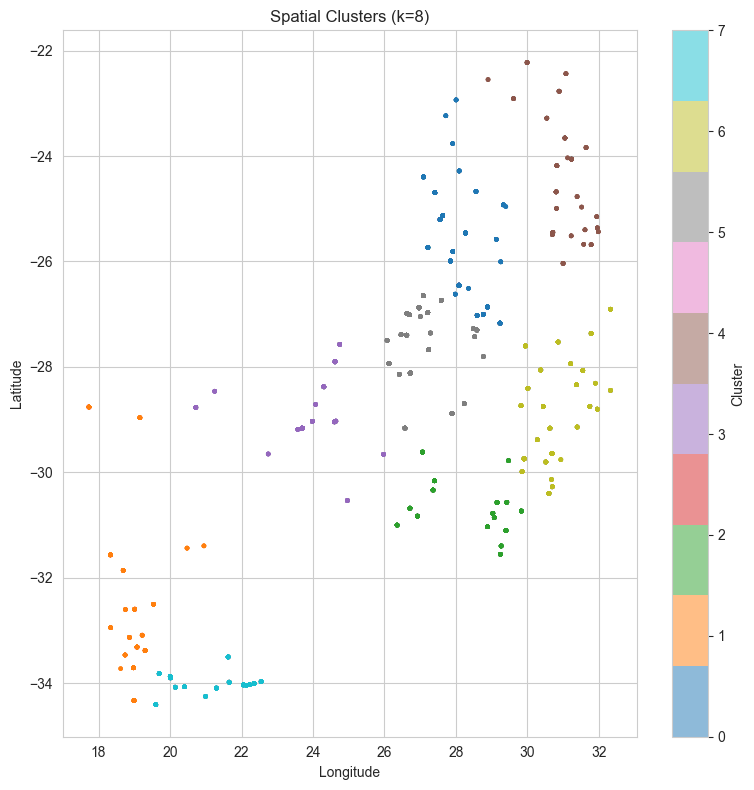

Cluster distribution:
Cluster
0.0    1741
1.0     693
2.0     945
3.0     790
4.0     618
5.0    2454
6.0    1336
7.0     742
Name: count, dtype: int64


In [45]:
# Spatial clustering (same concept as 03)
N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)

train_df["Cluster"] = kmeans.fit_predict(train_df[["Latitude", "Longitude"]]).astype(float)
val_df["Cluster"] = kmeans.predict(val_df[["Latitude", "Longitude"]]).astype(float)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
scatter = ax.scatter(
    train_df["Longitude"], train_df["Latitude"],
    c=train_df["Cluster"], cmap="tab10", s=5, alpha=0.5,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Spatial Clusters (k={N_CLUSTERS})")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

print(f"Cluster distribution:\n{train_df['Cluster'].value_counts().sort_index()}")

In [46]:
# Feature sets (same structure as 03, expanded to include all new combined features)
BASELINE_FEATURES = ["swir22", "NDMI", "MNDWI", "pet"]

CURATED_FEATURES = [
    "swir22", "NDMI", "MNDWI", "pet",
    "Latitude", "Longitude", "Cluster",
    "NDVI", "BSI", "Chlorophyll_Proxy",
    "Month", "landsat_missing",
]

# Use numeric enhanced features, including encoded season_* columns but excluding raw text columns.
ALL_ENHANCED_FEATURES = [
    c for c in train_df.columns
    if c not in TARGETS
    and c != "Sample Date"
    and not c.startswith("Unnamed:")
    and pd.api.types.is_numeric_dtype(train_df[c])
]

BASELINE_FEATURES = [c for c in BASELINE_FEATURES if c in train_df.columns]
CURATED_FEATURES = [c for c in CURATED_FEATURES if c in train_df.columns]
ALL_ENHANCED_FEATURES = [c for c in ALL_ENHANCED_FEATURES if c in train_df.columns]

print(f"Baseline features ({len(BASELINE_FEATURES)}): {BASELINE_FEATURES}")
print(f"Curated features  ({len(CURATED_FEATURES)}): {CURATED_FEATURES}")
print(f"All enhanced      ({len(ALL_ENHANCED_FEATURES)}), {ALL_ENHANCED_FEATURES}")

Baseline features (4): ['swir22', 'NDMI', 'MNDWI', 'pet']
Curated features  (11): ['swir22', 'NDMI', 'MNDWI', 'pet', 'Latitude', 'Longitude', 'Cluster', 'NDVI', 'BSI', 'Chlorophyll_Proxy', 'landsat_missing']
All enhanced      (63), ['Latitude', 'Longitude', 'nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'NDVI', 'NDWI', 'NDSI_water', 'NDTI', 'Turbidity_Index', 'Chlorophyll_Proxy', 'BSI', 'SWIR22_NIR_ratio', 'SWIR16_NIR_ratio', 'Green_NIR_ratio', 'SWIR22_Green_ratio', 'SWIR16_Green_ratio', 'log_nir', 'log_green', 'log_swir16', 'log_swir22', 'nir_squared', 'swir22_squared', 'red', 'blue', 'lwir11', 'NDVI_red', 'EVI', 'SAVI', 'BSI_full', 'AWEI_nsh', 'AWEI_sh', 'NRI', 'Red_Blue_ratio', 'Green_Red_ratio', 'Turbidity_Red', 'pet', 'ppt', 'tmax', 'tmin', 'soil', 'aet', 'def', 'pdsi', 'q', 'elevation', 'land_cover', 'year', 'month', 'quarter', 'day_of_year', 'week_of_year', 'is_wet_season', 'months_since_start', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'landsat_missi

In [29]:
# CV utilities (same style as 03)
neg_rmse_scorer = make_scorer(lambda yt, yp: -np.sqrt(mean_squared_error(yt, yp)))

def cv_evaluate(model, X, y, cv=None, label="", target_name=""):
    if cv is None:
        cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    r2_scores = cross_val_score(model, X, y, cv=cv, scoring="r2", n_jobs=-1)
    rmse_scores = -cross_val_score(model, X, y, cv=cv, scoring=neg_rmse_scorer, n_jobs=-1)

    result = {
        "Model": label,
        "Target": target_name,
        "R2_mean": round(r2_scores.mean(), 4),
        "R2_std": round(r2_scores.std(), 4),
        "RMSE_mean": round(rmse_scores.mean(), 4),
        "RMSE_std": round(rmse_scores.std(), 4),
    }
    return result


baseline_rf = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("BASELINE MODEL (same as 03) — 5-fold CV")
baseline_results = []
for target in TARGETS:
    X = train_df[BASELINE_FEATURES].values
    y = train_df[target].values
    baseline_results.append(cv_evaluate(baseline_rf, X, y, label="Baseline RF", target_name=target))

baseline_df = pd.DataFrame(baseline_results)
baseline_df

BASELINE MODEL (same as 03) — 5-fold CV


,Model,Target,R2_mean,R2_std,RMSE_mean,RMSE_std
0,Baseline RF,Total Alkalinity,0.5183,0.0068,51.8236,0.5446
1,Baseline RF,Electrical Conductance,0.5455,0.0113,230.4644,5.2633
2,Baseline RF,Dissolved Reactive Phosphorus,0.5100,0.0158,35.6653,0.8993


In [30]:
# Curated feature benchmark + log-transform wrapper
curated_results = []
for target in TARGETS:
    X = train_df[CURATED_FEATURES].values
    y = train_df[target].values
    curated_results.append(cv_evaluate(baseline_rf, X, y, label="Curated RF", target_name=target))

curated_df = pd.DataFrame(curated_results)

class LogTransformedRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        self.model_ = clone(self.base_estimator)
        self.model_.fit(X, np.log1p(y))
        return self

    def predict(self, X):
        return np.expm1(self.model_.predict(X))


log_rf = LogTransformedRegressor(baseline_rf)
log_results = []
for target in TARGETS:
    X = train_df[CURATED_FEATURES].values
    y = train_df[target].values
    log_results.append(cv_evaluate(log_rf, X, y, label="Curated log1p RF", target_name=target))

log_df = pd.DataFrame(log_results)
pd.concat([baseline_df, curated_df, log_df], ignore_index=True)

,Model,Target,R2_mean,R2_std,RMSE_mean,RMSE_std
0,Baseline RF,Total Alkalinity,0.5183,0.0068,51.8236,0.5446
1,Baseline RF,Electrical Conductance,0.5455,0.0113,230.4644,5.2633
2,Baseline RF,Dissolved Reactive Phosphorus,0.5100,0.0158,35.6653,0.8993
3,Curated RF,Total Alkalinity,0.8153,0.0104,32.0713,0.7904
4,Curated RF,Electrical Conductance,0.8342,0.0032,139.1693,0.9812
5,Curated RF,Dissolved Reactive Phosphorus,0.6700,0.0059,29.2673,0.4079
6,Curated log1p RF,Total Alkalinity,0.7971,0.0119,33.6219,0.9941
7,Curated log1p RF,Electrical Conductance,0.8139,0.0059,147.4462,2.3162
8,Curated log1p RF,Dissolved Reactive Phosphorus,0.6111,0.0105,31.7801,0.8664


In [31]:
# Model family comparison on curated features (same as 03)
xgb_model = None
if HAS_XGB:
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

lgbm_model = None
if HAS_LGBM:
    lgbm_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )

models = {"RF": baseline_rf}
if xgb_model is not None:
    models["XGBoost"] = xgb_model
if lgbm_model is not None:
    models["LightGBM"] = lgbm_model

comparison_results = []
for model_name, model in models.items():
    for target in TARGETS:
        X = train_df[CURATED_FEATURES].values
        y = train_df[target].values
        comparison_results.append(cv_evaluate(model, X, y, label=f"Curated {model_name}", target_name=target))

comparison_df = pd.DataFrame(comparison_results)

log_models = {"log1p RF": LogTransformedRegressor(baseline_rf)}
if xgb_model is not None:
    log_models["log1p XGBoost"] = LogTransformedRegressor(xgb_model)
if lgbm_model is not None:
    log_models["log1p LightGBM"] = LogTransformedRegressor(lgbm_model)

log_comparison_results = []
for model_name, model in log_models.items():
    for target in TARGETS:
        X = train_df[CURATED_FEATURES].values
        y = train_df[target].values
        log_comparison_results.append(cv_evaluate(model, X, y, label=f"Curated {model_name}", target_name=target))

log_comparison_df = pd.DataFrame(log_comparison_results)
pd.concat([comparison_df, log_comparison_df], ignore_index=True).sort_values(["Target", "R2_mean"], ascending=[True, False])

,Model,Target,R2_mean,R2_std,RMSE_mean,RMSE_std
5,Curated XGBoost,Dissolved Reactive Phosphorus,0.7013,0.0085,27.8416,0.1881
8,Curated LightGBM,Dissolved Reactive Phosphorus,0.6745,0.0060,29.0676,0.3863
2,Curated RF,Dissolved Reactive Phosphorus,0.6700,0.0059,29.2673,0.4079
14,Curated log1p XGBoost,Dissolved Reactive Phosphorus,0.6446,0.0067,30.3747,0.6015
11,Curated log1p RF,Dissolved Reactive Phosphorus,0.6111,0.0105,31.7801,0.8664
17,Curated log1p LightGBM,Dissolved Reactive Phosphorus,0.6068,0.0082,31.9553,0.8624
4,Curated XGBoost,Electrical Conductance,0.8608,0.0052,127.4694,0.7130
7,Curated LightGBM,Electrical Conductance,0.8486,0.0062,132.9398,1.2942
13,Curated log1p XGBoost,Electrical Conductance,0.8486,0.0049,132.9704,0.5672
1,Curated RF,Electrical Conductance,0.8342,0.0032,139.1693,0.9812


In [18]:
# Hyperparameter tuning (same approach as 03)
xgb_param_dist = {
    "base_estimator__n_estimators": randint(300, 1000),
    "base_estimator__max_depth": randint(3, 10),
    "base_estimator__learning_rate": uniform(0.01, 0.1),
    "base_estimator__subsample": uniform(0.6, 0.4),
    "base_estimator__colsample_bytree": uniform(0.5, 0.5),
    "base_estimator__reg_alpha": uniform(0.0, 0.5),
    "base_estimator__reg_lambda": uniform(0.5, 1.5),
}

lgbm_param_dist = {
    "base_estimator__n_estimators": randint(300, 1000),
    "base_estimator__max_depth": randint(3, 10),
    "base_estimator__learning_rate": uniform(0.01, 0.1),
    "base_estimator__subsample": uniform(0.6, 0.4),
    "base_estimator__colsample_bytree": uniform(0.5, 0.5),
    "base_estimator__reg_alpha": uniform(0.0, 0.5),
    "base_estimator__reg_lambda": uniform(0.5, 1.5),
}

rf_param_dist = {
    "base_estimator__n_estimators": randint(200, 900),
    "base_estimator__max_depth": randint(4, 25),
    "base_estimator__min_samples_leaf": randint(1, 8),
    "base_estimator__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],
}

cv_inner = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
best_models = {}
tuning_results = []

candidate_configs = [("log1p RF", LogTransformedRegressor(baseline_rf), rf_param_dist)]
if xgb_model is not None:
    candidate_configs.append(("log1p XGBoost", LogTransformedRegressor(xgb_model), xgb_param_dist))
if lgbm_model is not None:
    candidate_configs.append(("log1p LightGBM", LogTransformedRegressor(lgbm_model), lgbm_param_dist))

for target in TARGETS:
    print(f"\n{'=' * 80}")
    print(f"Tuning for: {target}")
    print(f"{'=' * 80}")

    X = train_df[CURATED_FEATURES].values
    y = train_df[target].values

    best_score = -np.inf
    best_name = None
    best_est = None

    for name, base_model, param_dist in candidate_configs:
        search = RandomizedSearchCV(
            base_model,
            param_dist,
            n_iter=30,
            cv=cv_inner,
            scoring="r2",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X, y)

        tuning_results.append({
            "Target": target,
            "Model": name,
            "Best_R2_CV": round(search.best_score_, 4),
            "Best_Params": search.best_params_,
        })

        print(f"{name:16s} best R2 = {search.best_score_:.4f}")

        if search.best_score_ > best_score:
            best_score = search.best_score_
            best_name = name
            best_est = search.best_estimator_

    best_models[target] = (best_name, best_est)
    print(f"Selected: {best_name} (R2={best_score:.4f})")

tuning_df = pd.DataFrame(tuning_results)
tuning_df


Tuning for: Total Alkalinity


c:\Users\zhout\anaconda3\envs\eychallenge\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


log1p RF         best R2 = 0.8224
log1p XGBoost    best R2 = 0.8251
log1p LightGBM   best R2 = 0.8186
Selected: log1p XGBoost (R2=0.8251)

Tuning for: Electrical Conductance


c:\Users\zhout\anaconda3\envs\eychallenge\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\zhout\anaconda3\envs\eychallenge\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


log1p RF         best R2 = 0.8409
log1p XGBoost    best R2 = 0.8408
log1p LightGBM   best R2 = 0.8327
Selected: log1p RF (R2=0.8409)

Tuning for: Dissolved Reactive Phosphorus


c:\Users\zhout\anaconda3\envs\eychallenge\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


log1p RF         best R2 = 0.6342
log1p XGBoost    best R2 = 0.6405
log1p LightGBM   best R2 = 0.6281
Selected: log1p XGBoost (R2=0.6405)


,Target,Model,Best_R2_CV,Best_Params
0,Total Alkalinity,log1p RF,0.8224,"{'base_estimator__max_depth': 24, 'base_estima..."
1,Total Alkalinity,log1p XGBoost,0.8251,{'base_estimator__colsample_bytree': 0.7553736...
2,Total Alkalinity,log1p LightGBM,0.8186,{'base_estimator__colsample_bytree': 0.5115312...
3,Electrical Conductance,log1p RF,0.8409,"{'base_estimator__max_depth': 24, 'base_estima..."
4,Electrical Conductance,log1p XGBoost,0.8408,{'base_estimator__colsample_bytree': 0.9609371...
5,Electrical Conductance,log1p LightGBM,0.8327,{'base_estimator__colsample_bytree': 0.7238915...
6,Dissolved Reactive Phosphorus,log1p RF,0.6342,"{'base_estimator__max_depth': 24, 'base_estima..."
7,Dissolved Reactive Phosphorus,log1p XGBoost,0.6405,{'base_estimator__colsample_bytree': 0.7553736...
8,Dissolved Reactive Phosphorus,log1p LightGBM,0.6281,{'base_estimator__colsample_bytree': 0.5480882...


Target                           Dissolved Reactive Phosphorus  Electrical Conductance  Total Alkalinity
Experiment                                                                                              
1. Baseline RF                                          0.5100                  0.5455            0.5183
2. Curated RF                                           0.6562                  0.8266            0.8056
3. Curated log1p RF                                     0.5968                  0.8061            0.7847
4. Curated boosted models                               0.6791                  0.8467            0.8316
5. Curated log1p boosted models                         0.6249                  0.8330            0.8173
6. Tuned best model                                     0.6405                  0.8409            0.8251


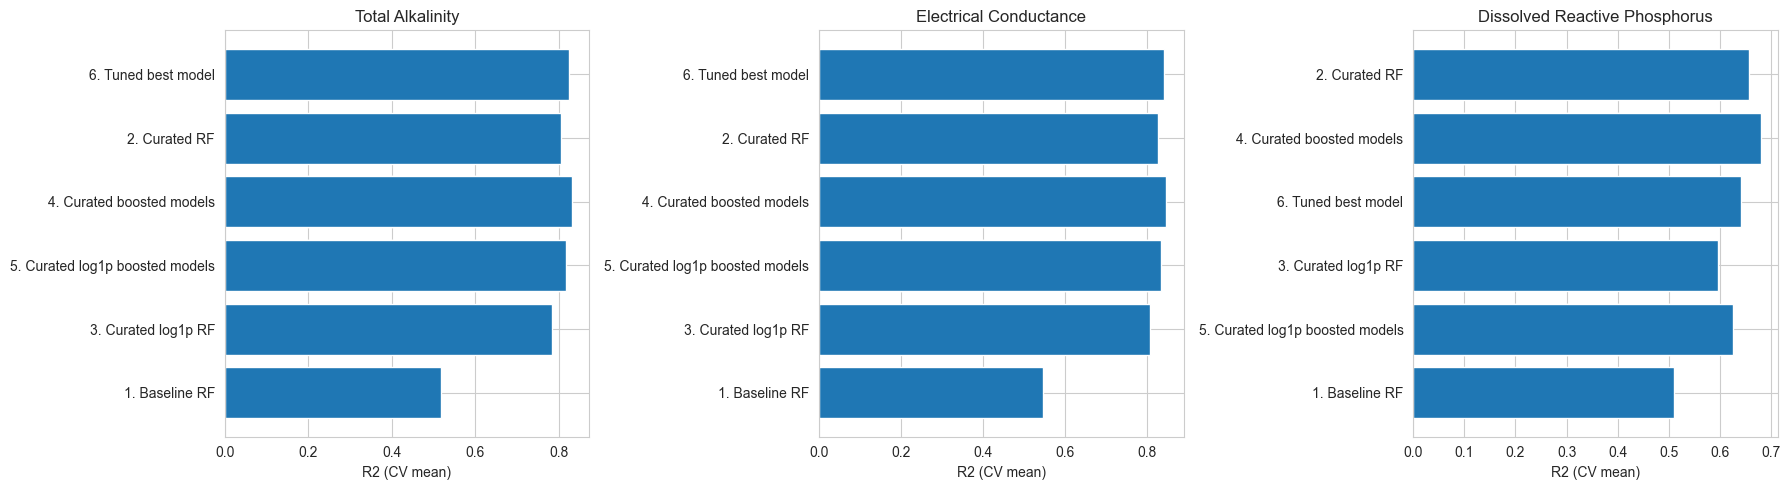

In [19]:
# Results summary table and comparison plots (same reporting intent as 03)
all_results = pd.concat([
    baseline_df.assign(Experiment="1. Baseline RF"),
    curated_df.assign(Experiment="2. Curated RF"),
    log_df.assign(Experiment="3. Curated log1p RF"),
    comparison_df.assign(Experiment="4. Curated boosted models"),
    log_comparison_df.assign(Experiment="5. Curated log1p boosted models"),
], ignore_index=True)

for target in TARGETS:
    name, _ = best_models[target]
    trow = tuning_df[(tuning_df["Target"] == target) & (tuning_df["Model"] == name)].iloc[0]
    all_results = pd.concat([
        all_results,
        pd.DataFrame([{
            "Model": name + " tuned",
            "Target": target,
            "R2_mean": trow["Best_R2_CV"],
            "R2_std": np.nan,
            "RMSE_mean": np.nan,
            "RMSE_std": np.nan,
            "Experiment": "6. Tuned best model",
        }]),
    ], ignore_index=True)

pivot = all_results.pivot_table(index="Experiment", columns="Target", values="R2_mean", aggfunc="max")
print(pivot.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, target in enumerate(TARGETS):
    subset = all_results[all_results["Target"] == target].sort_values("R2_mean")
    axes[i].barh(subset["Experiment"], subset["R2_mean"])
    axes[i].set_xlabel("R2 (CV mean)")
    axes[i].set_title(target)

plt.tight_layout()
plt.show()

C:\Users\zhout\AppData\Local\Temp\ipykernel_10304\2467972620.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(perm_imp.importances[sorted_idx].T, vert=False, labels=np.array(CURATED_FEATURES)[sorted_idx])
C:\Users\zhout\AppData\Local\Temp\ipykernel_10304\2467972620.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(perm_imp.importances[sorted_idx].T, vert=False, labels=np.array(CURATED_FEATURES)[sorted_idx])
C:\Users\zhout\AppData\Local\Temp\ipykernel_10304\2467972620.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(perm_imp.importances[sorted_idx].T, vert=Fals

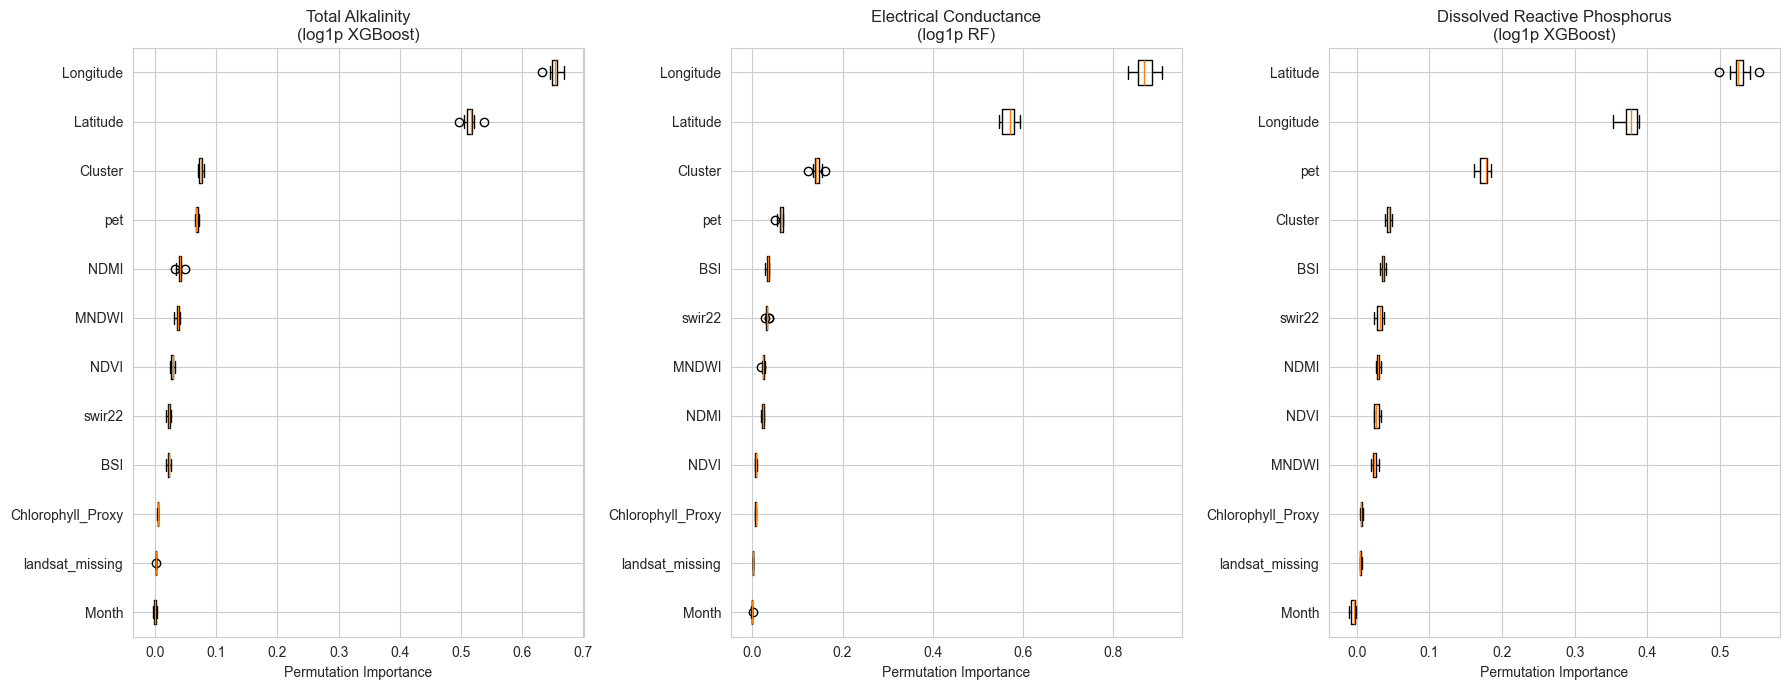

In [20]:
# Permutation importance diagnostics (same as 03)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, target in enumerate(TARGETS):
    name, model = best_models[target]
    X = train_df[CURATED_FEATURES].values
    y = train_df[target].values

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)

    perm_imp = permutation_importance(
        model,
        X_te,
        y_te,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    sorted_idx = perm_imp.importances_mean.argsort()
    axes[i].boxplot(perm_imp.importances[sorted_idx].T, vert=False, labels=np.array(CURATED_FEATURES)[sorted_idx])
    axes[i].set_title(f"{target}\n({name})")
    axes[i].set_xlabel("Permutation Importance")

plt.tight_layout()
plt.show()

In [21]:
# Improvement 1: leakage-resistant CV diagnostics (GroupKFold + time-aware split)
from sklearn.model_selection import GroupKFold


def time_block_splits(year_series, n_splits=4):
    """Create expanding time splits based on sorted years."""
    years = pd.Series(year_series).fillna(pd.Series(year_series).median()).astype(int).values
    order = np.argsort(years)
    fold_sizes = np.full(n_splits, len(order) // n_splits, dtype=int)
    fold_sizes[: len(order) % n_splits] += 1

    idx_blocks = []
    current = 0
    for fold_size in fold_sizes:
        idx_blocks.append(order[current: current + fold_size])
        current += fold_size

    splits = []
    for i in range(1, n_splits):
        train_idx = np.concatenate(idx_blocks[:i])
        test_idx = idx_blocks[i]
        if len(train_idx) > 0 and len(test_idx) > 0:
            splits.append((train_idx, test_idx))
    return splits


cv_diagnostics = []
for target in TARGETS:
    X = train_df[CURATED_FEATURES].values
    y = train_df[target].values

    # Group-based CV using spatial clusters
    gkf = GroupKFold(n_splits=5)
    group_r2 = cross_val_score(baseline_rf, X, y, cv=gkf.split(X, y, groups=train_df["Cluster"].values), scoring="r2", n_jobs=-1)

    # Time-aware expanding splits using year
    year_splits = time_block_splits(train_df["Year"], n_splits=5)
    time_scores = []
    for tr_idx, te_idx in year_splits:
        model = clone(baseline_rf)
        model.fit(X[tr_idx], y[tr_idx])
        preds = model.predict(X[te_idx])
        time_scores.append(1 - np.sum((y[te_idx] - preds) ** 2) / np.sum((y[te_idx] - y[te_idx].mean()) ** 2))

    cv_diagnostics.append({
        "Target": target,
        "R2_GroupKFold_mean": round(np.mean(group_r2), 4),
        "R2_GroupKFold_std": round(np.std(group_r2), 4),
        "R2_TimeSplit_mean": round(float(np.mean(time_scores)), 4) if len(time_scores) else np.nan,
        "R2_TimeSplit_std": round(float(np.std(time_scores)), 4) if len(time_scores) else np.nan,
    })

cv_diag_df = pd.DataFrame(cv_diagnostics)
print("Leakage-resistant CV diagnostics (Baseline RF on curated features):")
cv_diag_df

Leakage-resistant CV diagnostics (Baseline RF on curated features):


,Target,R2_GroupKFold_mean,R2_GroupKFold_std,R2_TimeSplit_mean,R2_TimeSplit_std
0,Total Alkalinity,-0.3377,0.5121,0.6969,0.0439
1,Electrical Conductance,-0.3801,0.3036,0.7309,0.0325
2,Dissolved Reactive Phosphorus,-0.3957,0.3029,0.5083,0.0741


In [22]:
# Improvement 2: full-feature tuning track (same tuning logic, ALL_ENHANCED_FEATURES)
best_models_enhanced = {}
tuning_results_enhanced = []

for target in TARGETS:
    print(f"\n{'=' * 80}")
    print(f"Enhanced tuning for: {target}")
    print(f"{'=' * 80}")

    X = train_df[ALL_ENHANCED_FEATURES].values
    y = train_df[target].values

    best_score = -np.inf
    best_name = None
    best_est = None

    for name, base_model, param_dist in candidate_configs:
        search = RandomizedSearchCV(
            base_model,
            param_dist,
            n_iter=20,
            cv=cv_inner,
            scoring="r2",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X, y)

        tuning_results_enhanced.append({
            "Target": target,
            "Model": name,
            "Best_R2_CV": round(search.best_score_, 4),
            "Best_Params": search.best_params_,
        })

        print(f"{name:16s} best R2 = {search.best_score_:.4f}")

        if search.best_score_ > best_score:
            best_score = search.best_score_
            best_name = name
            best_est = search.best_estimator_

    best_models_enhanced[target] = (best_name, best_est)
    print(f"Selected enhanced: {best_name} (R2={best_score:.4f})")

tuning_enhanced_df = pd.DataFrame(tuning_results_enhanced)
tuning_enhanced_df


Enhanced tuning for: Total Alkalinity


ValueError: 
All the 100 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\zhout\anaconda3\envs\eychallenge\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\zhout\AppData\Local\Temp\ipykernel_10304\2255756047.py", line 16, in fit
  File "c:\Users\zhout\anaconda3\envs\eychallenge\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\zhout\anaconda3\envs\eychallenge\Lib\site-packages\sklearn\ensemble\_forest.py", line 363, in fit
    X, y = self._validate_data(
           ^^

In [ ]:
# Improvement 3: OOF weighted ensemble (curated-best + enhanced-best)
def make_oof_predictions(model, X, y, cv):
    oof = np.zeros(len(y), dtype=float)
    for tr_idx, te_idx in cv.split(X, y):
        m = clone(model)
        m.fit(X[tr_idx], y[tr_idx])
        oof[te_idx] = m.predict(X[te_idx])
    return oof


final_submission_predictions = {}
final_submission_model_report = {}
ensemble_records = []

for target in TARGETS:
    y = train_df[target].values

    name_cur, model_cur = best_models[target]
    name_enh, model_enh = best_models_enhanced[target]

    X_cur_train = train_df[CURATED_FEATURES].values
    X_enh_train = train_df[ALL_ENHANCED_FEATURES].values
    X_cur_val = val_df[CURATED_FEATURES].values
    X_enh_val = val_df[ALL_ENHANCED_FEATURES].values

    oof_cur = make_oof_predictions(model_cur, X_cur_train, y, cv_inner)
    oof_enh = make_oof_predictions(model_enh, X_enh_train, y, cv_inner)

    best_w = 0.5
    best_r2 = -np.inf
    for w in np.linspace(0.0, 1.0, 21):
        oof_blend = w * oof_cur + (1 - w) * oof_enh
        sse = np.sum((y - oof_blend) ** 2)
        sst = np.sum((y - y.mean()) ** 2)
        r2 = 1 - sse / sst
        if r2 > best_r2:
            best_r2 = r2
            best_w = float(w)

    # Fit base models on full data, predict validation, and blend with best weight
    model_cur.fit(X_cur_train, y)
    model_enh.fit(X_enh_train, y)
    pred_cur = model_cur.predict(X_cur_val)
    pred_enh = model_enh.predict(X_enh_val)

    pred_blend = best_w * pred_cur + (1 - best_w) * pred_enh
    pred_blend = np.clip(pred_blend, a_min=0, a_max=None)

    final_submission_predictions[target] = pred_blend
    final_submission_model_report[target] = f"OOFBlend[{name_cur}*{best_w:.2f} + {name_enh}*{1-best_w:.2f}]"

    ensemble_records.append({
        "Target": target,
        "Curated_Model": name_cur,
        "Enhanced_Model": name_enh,
        "Weight_Curated": round(best_w, 3),
        "Weight_Enhanced": round(1 - best_w, 3),
        "OOF_R2": round(best_r2, 4),
    })

ensemble_df = pd.DataFrame(ensemble_records)
print("Selected OOF blending weights:")
ensemble_df

In [ ]:
# Final training on full training set + validation predictions
# If weighted ensemble predictions were computed, use them; otherwise fallback to curated best models.
if "final_submission_predictions" in globals():
    predictions = final_submission_predictions
    selected_model_report = final_submission_model_report
else:
    X_train_full = train_df[CURATED_FEATURES].values
    X_val = val_df[CURATED_FEATURES].values

    predictions = {}
    selected_model_report = {}
    for target in TARGETS:
        name, model = best_models[target]
        y_full = train_df[target].values

        model.fit(X_train_full, y_full)
        preds = model.predict(X_val)
        preds = np.clip(preds, a_min=0, a_max=None)
        predictions[target] = preds
        selected_model_report[target] = name

for target in TARGETS:
    preds = predictions[target]
    model_name = selected_model_report.get(target, "unknown")
    print(
        f"{target:28s} | model={model_name:24s} | "
        f"mean={preds.mean():.2f}, std={preds.std():.2f}, "
        f"min={preds.min():.2f}, max={preds.max():.2f}"
    )

submission_df = pd.DataFrame({
    "Latitude": submission_template["Latitude"].values,
    "Longitude": submission_template["Longitude"].values,
    "Sample Date": submission_template["Sample Date"].values,
    "Total Alkalinity": predictions["Total Alkalinity"],
    "Electrical Conductance": predictions["Electrical Conductance"],
    "Dissolved Reactive Phosphorus": predictions["Dissolved Reactive Phosphorus"],
})

submission_df.to_csv("submission_final_modeling.csv", index=False)
print(f"\nSubmission saved: submission_final_modeling.csv ({submission_df.shape})")
submission_df.head(10)

In [ ]:
# Distribution sanity check (same as 03)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, target in enumerate(TARGETS):
    axes[i].hist(train_df[target].values, bins=50, alpha=0.5, label="Training", density=True)
    axes[i].hist(predictions[target], bins=30, alpha=0.7, label="Predicted", density=True)
    axes[i].set_title(target)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

axes[0].legend()
plt.tight_layout()
plt.savefig("submission_distributions_final_modeling.png", dpi=150, bbox_inches="tight")
plt.show()

print("Done. Reproduction pipeline complete with combined features.")

## Notes

- This notebook keeps the `03_prem_modeling.ipynb` modeling pattern and swaps in combined feature inputs.
- It preserves spatial clustering, log-target modeling, tuned model selection, and final submission generation.
- If runtime is high, lower `n_iter` in `RandomizedSearchCV` from 30 to 10-15.